# Download and Read OpenMesh Dataset from Zenodo

This notebook demonstrates how to:
1. Download the OpenMesh dataset from Zenodo
2. Extract the ZIP archive
3. Read and explore the NetCDF files

**Dataset:** https://zenodo.org/records/15287692

In [1]:
# Install required packages (uncomment if needed)
# !pip install requests xarray netCDF4 matplotlib pandas tqdm

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import OpenMesh tools
from openmesh import *
print("✓ All packages imported successfully")

✓ All packages imported successfully


## 1. Download and Extract Dataset

1. **Download** ZIP (~13 MB) → `archived/openmesh/`
2. **Extract** (~330 MB):
   - `organize=True` → `.nc` to `raw/`, `.csv` to `meta/`, `.ipynb` to `examples/`
   - `organize=False` → all files to `extracted/`

**Note:** Existing notebooks in `examples/` are not replaced. Use `organize=False` to get original Zenodo notebooks.

In [3]:
# =============================================================================
# OpenMesh Data Setup
# =============================================================================

# Download ZIP (skips if exists)
zip_path = download_openmesh()

# Extract & organize files
extract_openmesh(organize=True)

Archive directory: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/archived/openmesh
✓ File already exists: OpenMesh.zip
✓ File size: 13.10 MB
Extracting: OpenMesh.zip
  Raw data → /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh
  Metadata → /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/meta
  Examples → /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/examples (skips if exists)



Extracting:   0%|          | 0/14 [00:00<?, ?it/s]


✓ Already exist: 10 files (332.7 MB):
    pws_opensense_sample_jan.nc (9.4 MB)
    ds_openmesh.nc (305.4 MB)
    README.txt (0.0 MB)
    pws_metadata.csv (0.0 MB)
    ASOS_stations.csv (0.0 MB)
    links_metadata.csv (0.0 MB)
    read_pws_sample.ipynb (1.0 MB)
    openmesh_dataset_example.ipynb (0.6 MB)
    frequency_map.html (0.5 MB)
    directional_map.html (0.5 MB)


{'existing': {'raw': ['pws_opensense_sample_jan.nc', 'ds_openmesh.nc'],
  'meta': ['README.txt',
   'pws_metadata.csv',
   'ASOS_stations.csv',
   'links_metadata.csv'],
  'examples': ['read_pws_sample.ipynb', 'openmesh_dataset_example.ipynb'],
  'maps': ['frequency_map.html', 'directional_map.html']}}

## 2. Read Microwave Links Data

In [4]:
# Load links dataset
ds_links = load_links()
print("\n MICROWAVE LINKS DATASET")
print("=" * 60)

ds_links

✓ Loaded links data: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh/ds_openmesh.nc

 MICROWAVE LINKS DATASET


<xarray.Dataset> Size: 322MB
Dimensions:       (cml_id: 75, sublink_id: 3, time: 354241)
Coordinates:
  * time          (time) datetime64[ns] 3MB 2023-10-29 ... 2024-07-01
  * sublink_id    (sublink_id) object 24B 'sublink_1' 'sublink_2' 'sublink_3'
    site_0_lat    (cml_id) float32 300B ...
    site_0_lon    (cml_id) float32 300B ...
    site_1_lat    (cml_id) float32 300B ...
    site_1_lon    (cml_id) float32 300B ...
    length        (cml_id) float32 300B ...
    frequency     (cml_id, sublink_id) float32 900B ...
    polarization  (cml_id, sublink_id) object 2kB ...
  * cml_id        (cml_id) <U2 600B '1' '2' '3' '4' '5' ... '72' '73' '74' '75'
Data variables:
    rsl           (cml_id, sublink_id, time) float32 319MB ...
Attributes:
    title:                 OpenMesh
    file_author:           Dror Jacoby
    institution:           Cellular Environmental Monitoring (CellEnMon) Lab,...
    date:                  2025-11-01
    source:                Community NYC Mesh Wireless Network
    history:               2025-11-01: Updated metadata, converted netCDF → O...
    naming_convention:     OpenSense-1.0
    license_restrictions:  CC BY 4.0 – https://creativecommons.org/licenses/b...
    reference:             https://doi.org/10.5281/zenodo.15287692
    comment:               OpenMesh: Wireless Signal Dataset for Opportunisti...
    Conventions:           OpenSense-CML-v1.0

In [5]:
# Dataset attributes
ds_links.attrs

{'title': 'OpenMesh',
 'file_author': 'Dror Jacoby',
 'institution': 'Cellular Environmental Monitoring (CellEnMon) Lab, School of Electrical Engineering, Tel-Aviv University; Wireless and Mobile Networking (WiMNet) Lab, Department of Electrical Engineering, Columbia University',
 'date': '2025-11-01',
 'source': 'Community NYC Mesh Wireless Network',
 'history': '2025-11-01: Updated metadata, converted netCDF → OpenSense-1.0 CML format',
 'naming_convention': 'OpenSense-1.0',
 'license_restrictions': 'CC BY 4.0 – https://creativecommons.org/licenses/by/4.0/',
 'reference': 'https://doi.org/10.5281/zenodo.15287692',
 'comment': 'OpenMesh: Wireless Signal Dataset for Opportunistic Urban Weather Sensing in New York City. Data covers the period 2023-10-29 to 2024-07-01 (UTC). All timestamps are in UTC. Signal levels are in dBm. This dataset is described in the associated publication: https://essd.copernicus.org/preprints/essd-2025-238/',
 'Conventions': 'OpenSense-CML-v1.0'}

## 3. Quick Visualization

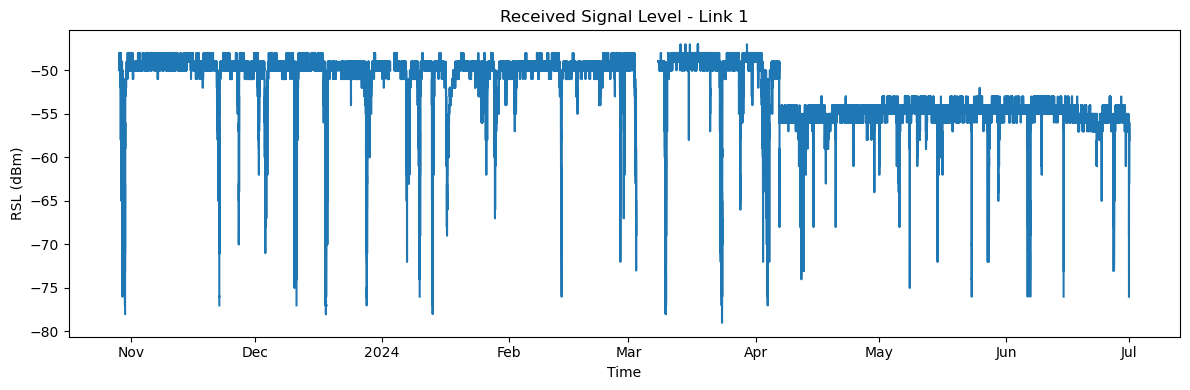

In [6]:
# Plot signal level for one link
fig, ax = plt.subplots(figsize=(12, 4))

link_id = '1'
ds_links['rsl'].sel(cml_id=link_id, sublink_id=['sublink_1']).plot(ax=ax)

ax.set_title(f'Received Signal Level - Link {link_id}')
ax.set_xlabel('Time')
ax.set_ylabel('RSL (dBm)')
plt.tight_layout()
plt.show()

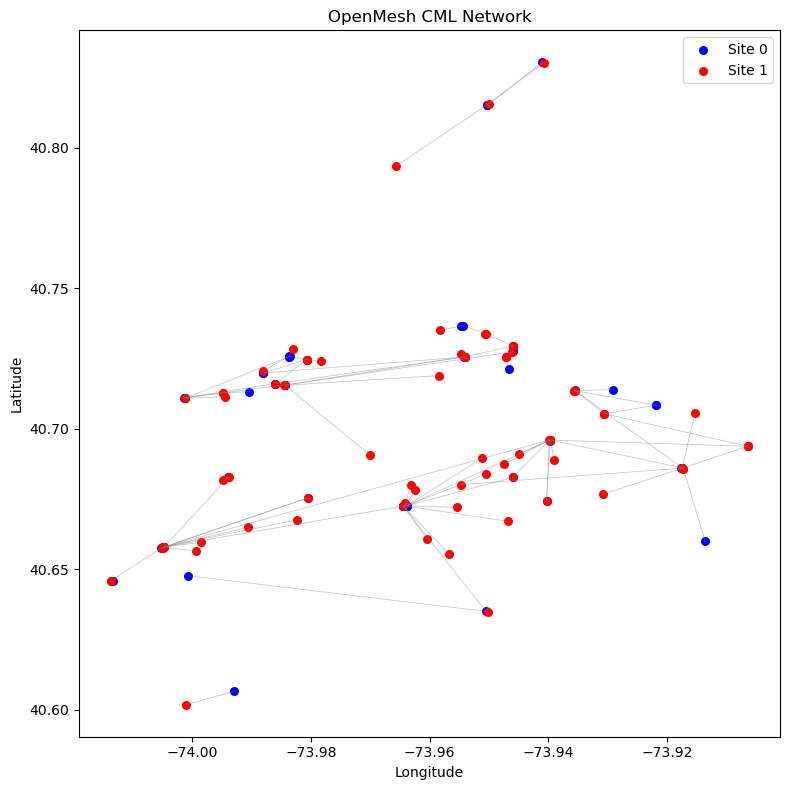

In [7]:
# Plot link locations
fig, ax = plt.subplots(figsize=(8, 8) )

ax.scatter(ds_links['site_0_lon'], ds_links['site_0_lat'], c='blue', label='Site 0', s=30)
ax.scatter(ds_links['site_1_lon'], ds_links['site_1_lat'], c='red', label='Site 1', s=30)

# Draw links
for i in range(len(ds_links.cml_id)):
    ax.plot(
        [ds_links['site_0_lon'].values[i], ds_links['site_1_lon'].values[i]],
        [ds_links['site_0_lat'].values[i], ds_links['site_1_lat'].values[i]],
        'gray', alpha=0.5, linewidth=0.5
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('OpenMesh CML Network')
ax.legend()
plt.tight_layout()
plt.show()

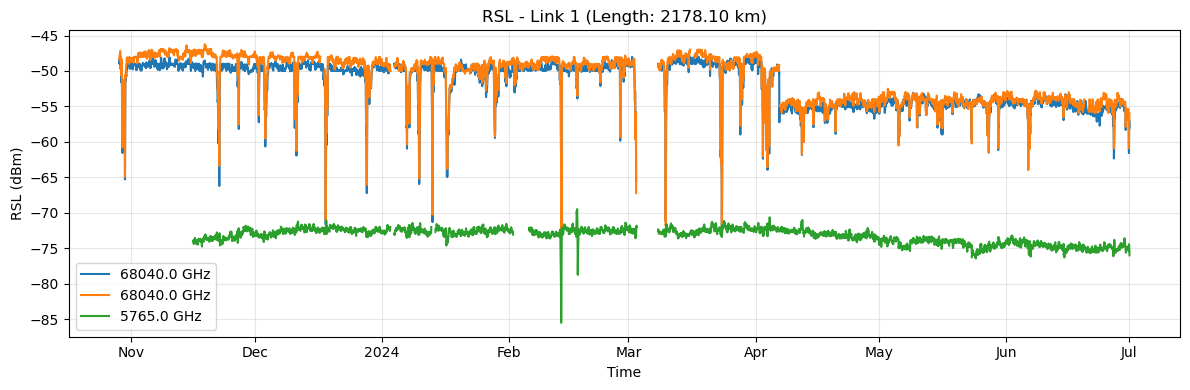

In [8]:
link_id = '1'

# Get length and frequency for this link
length = ds_links['length'].sel(cml_id=link_id).values
freqs = ds_links['frequency'].sel(cml_id=link_id).values  # array of 3 freqs

# Create custom labels with frequency
ds_plot = ds_links['rsl'].sel(cml_id=link_id).resample(time='1h').mean()

fig, ax = plt.subplots(figsize=(12, 4))

for i, sublink in enumerate(ds_links.sublink_id.values):
    freq = freqs[i]
    if not np.isnan(freq):
        ds_plot.sel(sublink_id=sublink).plot(ax=ax, label=f'{freq:.1f} GHz')

ax.legend()
ax.set_title(f"RSL - Link {link_id} (Length: {length:.2f} km)")
ax.set_ylabel("RSL (dBm)")
ax.set_xlabel("Time")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

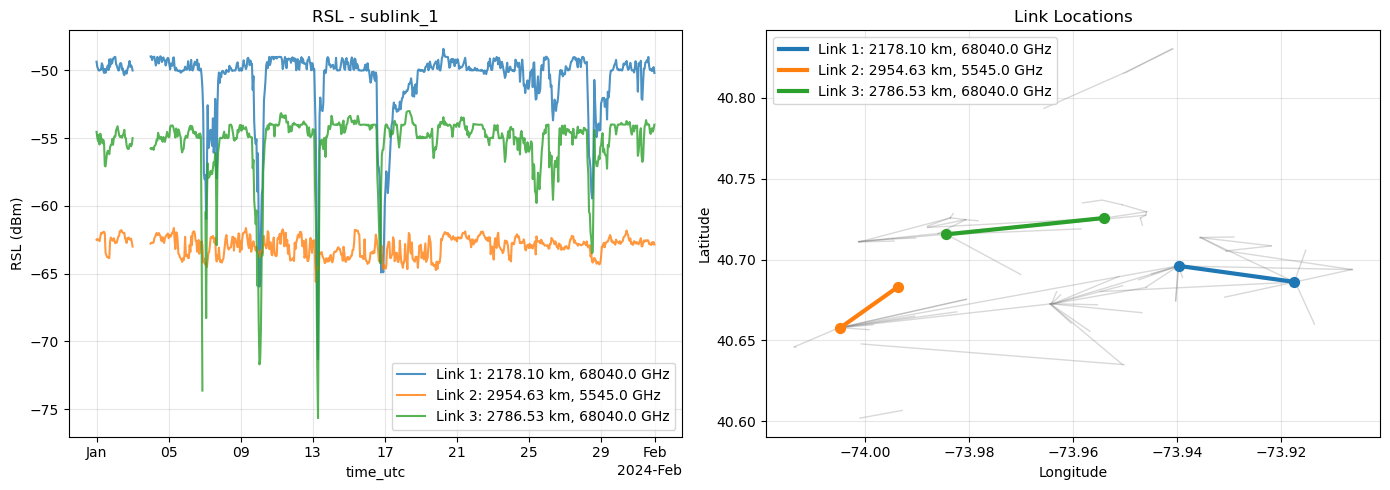

In [9]:
# Choose links and time period
link_ids = ['1', '2', '3']
sublink = 'sublink_1'
time_slice = slice('2024-01-01', '2024-01-31')  # January 2024

fig, (ax_rsl, ax_map) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors[:len(link_ids)]

# Get metadata for selected links
ds_sel_meta = ds_links.sel(cml_id=link_ids)
lengths = ds_sel_meta['length'].values
freqs = ds_sel_meta['frequency'].sel(sublink_id=sublink).values

# Left: RSL time series
for i, link_id in enumerate(link_ids):
    label = f"Link {link_id}: {lengths[i]:.2f} km, {freqs[i]:.1f} GHz"
    ds_links['rsl'].sel(cml_id=link_id, sublink_id=sublink, time=time_slice) \
        .resample(time='1h').mean() \
        .plot.line(x='time', ax=ax_rsl, color=colors[i], label=label, alpha=0.8)

ax_rsl.set_title(f"RSL - {sublink}")
ax_rsl.set_ylabel("RSL (dBm)")
ax_rsl.legend()
ax_rsl.grid(True, alpha=0.3)

# Right: Map - all links gray
ax_map.plot(
    [ds_links['site_0_lon'].values, ds_links['site_1_lon'].values],
    [ds_links['site_0_lat'].values, ds_links['site_1_lat'].values],
    'gray', alpha=0.3, linewidth=1
)

# Selected links with metadata
for i, link_id in enumerate(link_ids):
    ds_link = ds_links.sel(cml_id=link_id)
    label = f"Link {link_id}: {lengths[i]:.2f} km, {freqs[i]:.1f} GHz"
    ax_map.plot(
        [ds_link['site_0_lon'].values, ds_link['site_1_lon'].values],
        [ds_link['site_0_lat'].values, ds_link['site_1_lat'].values],
        color=colors[i], linewidth=3, label=label
    )
    ax_map.scatter(
        [ds_link['site_0_lon'].values, ds_link['site_1_lon'].values],
        [ds_link['site_0_lat'].values, ds_link['site_1_lat'].values],
        color=colors[i], s=50, zorder=5
    )

ax_map.set_xlabel("Longitude")
ax_map.set_ylabel("Latitude")
ax_map.set_title("Link Locations")
ax_map.legend()
ax_map.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

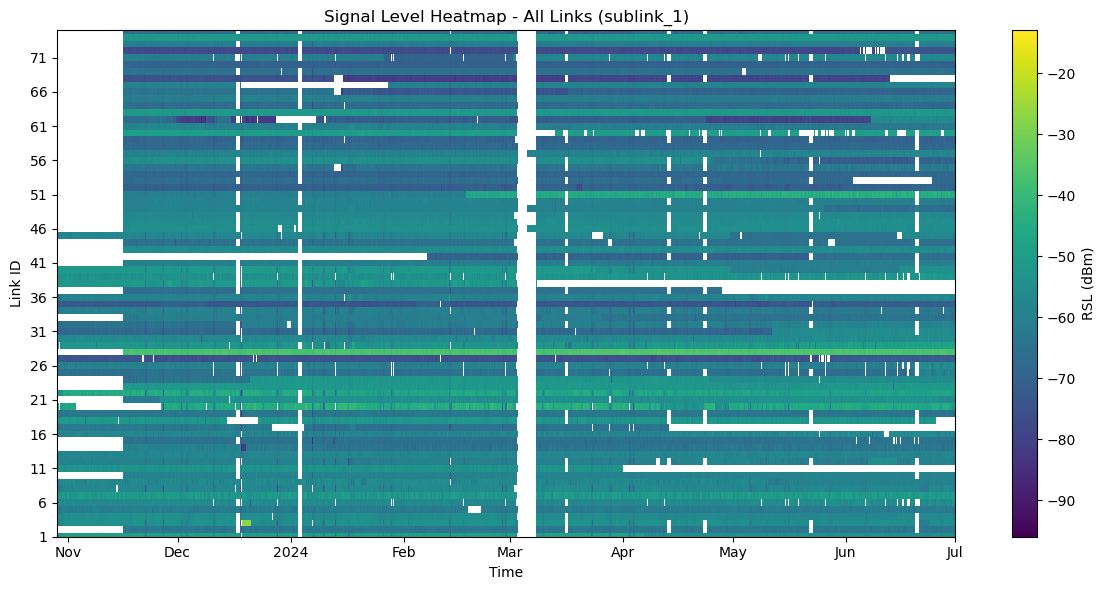

In [10]:
# Heatmap with cleaner labels
fig, ax = plt.subplots(figsize=(12, 6))

ds_links['rsl'].sel(sublink_id='sublink_1').plot(
    x='time',
    y='cml_id',
    ax=ax,
    cbar_kwargs={'label': 'RSL (dBm)'}
)

ax.set_title("Signal Level Heatmap - All Links (sublink_1)")
ax.set_ylabel("Link ID")
ax.set_xlabel("Time")

# Show fewer y-ticks (every 5th link)
ax.set_yticks(ax.get_yticks()[::5])

plt.tight_layout()
plt.show()

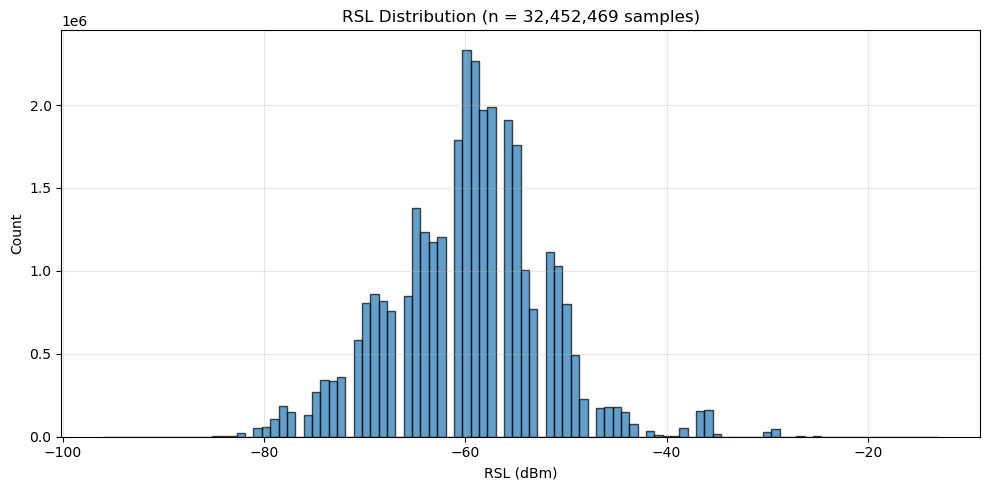

In [11]:
# Histogram of all RSL values
fig, ax = plt.subplots(figsize=(10, 5))

# Flatten all RSL data and drop NaNs
rsl_values = ds_links['rsl'].values.flatten()
rsl_values = rsl_values[~np.isnan(rsl_values)]

ax.hist(rsl_values, bins=100, edgecolor='black', alpha=0.7)

ax.set_title(f"RSL Distribution (n = {len(rsl_values):,} samples)")
ax.set_xlabel("RSL (dBm)")
ax.set_ylabel("Count")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Dataset Summary
time_min = pd.Timestamp(ds_links.time.min().values).strftime('%Y-%m-%d %H:%M')
time_max = pd.Timestamp(ds_links.time.max().values).strftime('%Y-%m-%d %H:%M')
duration = (pd.Timestamp(ds_links.time.max().values) - pd.Timestamp(ds_links.time.min().values)).days
res_min = int(pd.Timedelta(ds_links.time.diff('time').median().values).total_seconds() // 60)

print(f"Title: {ds_links.attrs.get('title', 'N/A')}")
print(f"Time: {time_min} → {time_max} ({duration} days)")
print(f"Links: {len(ds_links.cml_id)} | Sublinks: {len(ds_links.sublink_id)} | Timesteps: {len(ds_links.time):,} | Resolution: {res_min} min")
print(f"Variables: {', '.join(list(ds_links.data_vars))}")

# Link characteristics
freq = ds_links['frequency'].values / 1000  # MHz to GHz
length = ds_links['length'].values
print(f"Frequency: {np.nanmin(freq):.1f} - {np.nanmax(freq):.1f} GHz | Length: {np.nanmin(length):.0f} - {np.nanmax(length):.0f} m")

# Geographic extent
lat = np.concatenate([ds_links['site_0_lat'].values, ds_links['site_1_lat'].values])
lon = np.concatenate([ds_links['site_0_lon'].values, ds_links['site_1_lon'].values])
print(f"Bounds: lat [{np.nanmin(lat):.4f}, {np.nanmax(lat):.4f}] | lon [{np.nanmin(lon):.4f}, {np.nanmax(lon):.4f}]")

# Polarization
pol = ds_links['polarization'].values.flatten()
pol_counts = pd.Series(pol).value_counts().to_dict()
print(f"Polarization: {pol_counts}")

# Coverage
print(f"Coverage: rsl {ds_links['rsl'].count().values / ds_links['rsl'].size * 100:.1f}%")

# Memory
print(f"Size: {ds_links.nbytes / 1e9:.2f} GB")


Title: OpenMesh
Time: 2023-10-29 00:00 → 2024-07-01 00:00 (246 days)
Links: 75 | Sublinks: 3 | Timesteps: 354,241 | Resolution: 1 min
Variables: rsl
Frequency: 5.3 - 69.1 GHz | Length: 24 - 6936 m
Bounds: lat [40.6019, 40.8304] | lon [-74.0137, -73.9064]
Polarization: {'v': 225}
Coverage: rsl 40.7%
Size: 0.32 GB


# PWS Data Loading

**Two sources available:**
- **OpenSense** → `load_pws(sample=True/False)`
- **Weather Underground** → `load_pws_wu(sample=True/False)`

`sample=True` = quick testing | `sample=False` = full dataset

In [13]:
# =============================================================================
# PWS Data Setup
# =============================================================================

download_data = True      # Set False to skip download
use_sample =  False        # True = sample, False = full (requires download)

# Download & Extract (full data only)
if download_data and not use_sample:
    download_pws_wu()
    extract_pws_wu()

# Load
pws_data = load_pws(sample=use_sample)

✓ File already exists: PWS_NYC_WU.zip
✓ Downloaded: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/archived/openmesh/PWS_NYC_WU.zip
Next: Run extract_pws_wu() to extract data
✓ Already extracted: /Users/drorjac/PycharmProjects/OpenMesh-fresh/dataset/raw/openmesh/pws_wu_os.nc
Loading: pws_wu_os.nc


✓ Loaded 37 stations


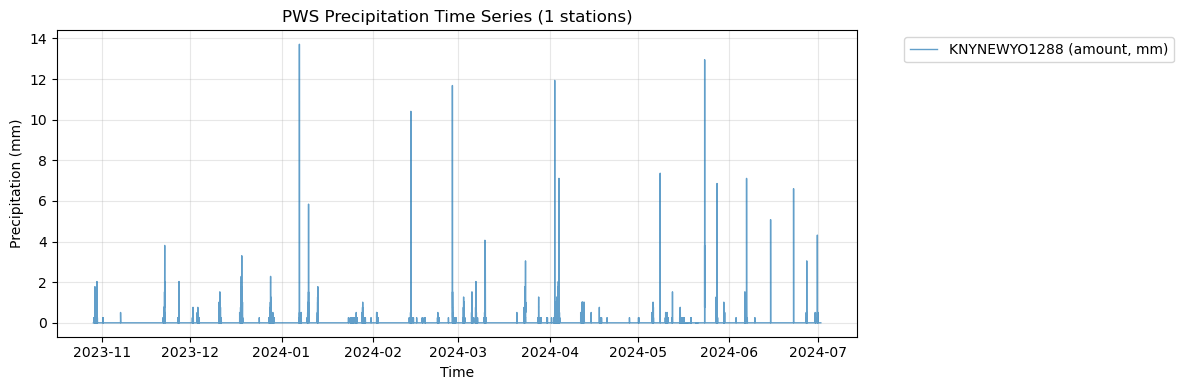

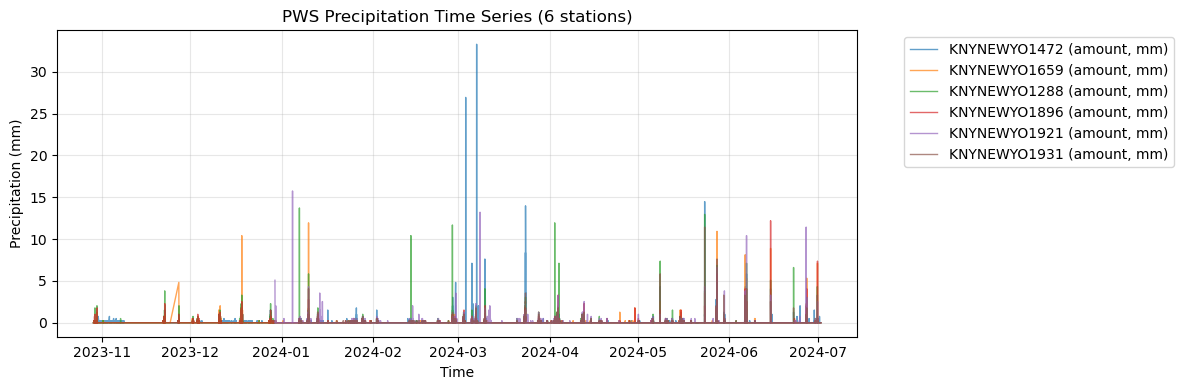

In [14]:


# # Plot specific stations
plot_pws_precipitation(pws_data, station_ids=['KNYNEWYO1288'])

# # # Or plot first 3 stations
plot_pws_precipitation(pws_data, max_stations=6)




📊 Examining station: KNYNEWYO1472
Dataset: N/A

Time range: 2023-10-29T04:04:00.000000000 to 2024-07-01T23:59:00.000000000
Number of timesteps: 60339
Temporal resolution: 0 days 00:05:00

Available variables: ['rainfall_rate', 'rainfall_amount', 'temperature', 'relative_humidity', 'wind_velocity', 'wind_direction', 'air_pressure']


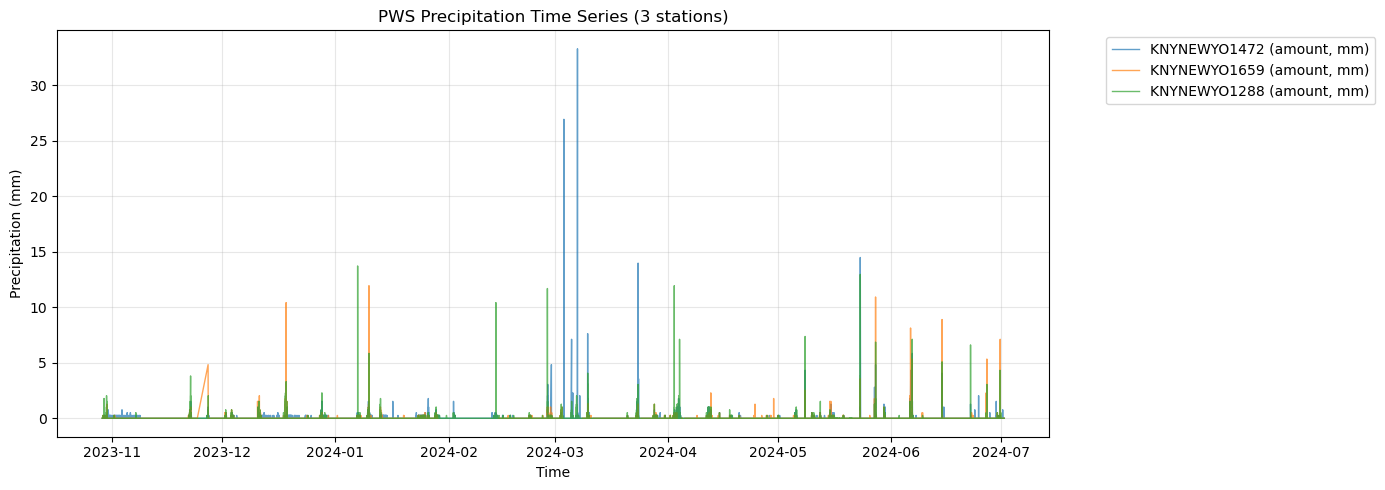

In [15]:
# Get basic info about first station
first_station_id = list(pws_data.keys())[0]
print(f"\n📊 Examining station: {first_station_id}")
print("=" * 60)

ds_pws = pws_data[first_station_id]
print_summary(ds_pws)

# Show available variables

print(f"\nAvailable variables: {list(ds_pws.data_vars)}")

# Plot precipitation for first 3 stations
plot_pws_precipitation(pws_data, max_stations=3, figsize=(14, 5))

In [16]:
# Analyze ALL stations and create summary table
station_stats = []

for station_id in pws_data.keys():
    df_pws = pws_to_dataframe(pws_data, station_id=station_id)
    rainy_periods = df_pws[df_pws['rainfall_mm'] > 0]
    
    stats = {
        'Station ID': station_id,
        'Records': len(df_pws),
        'Days': round((df_pws.index.max() - df_pws.index.min()).total_seconds() / 86400, 1),
        'Total Rain (mm)': round(df_pws['rainfall_mm'].sum(), 2),
        'Max Rain (mm)': round(df_pws['rainfall_mm'].max(), 2),
        'Rainy %': round(100 * len(rainy_periods) / len(df_pws), 1),
        'Missing %': round(100 * df_pws['rainfall_mm'].isna().sum() / len(df_pws), 1)
    }
    
    station_stats.append(stats)

# Create summary DataFrame
df_summary = pd.DataFrame(station_stats)

print(f"\n📊 SUMMARY: {len(df_summary)} PWS Stations")
print("=" * 90)
print(df_summary.to_string(index=False))

# Highlight key findings
print(f"\n🔍 Key Findings:")
print(f"  • Wettest station: {df_summary.loc[df_summary['Total Rain (mm)'].idxmax(), 'Station ID']} "
      f"({df_summary['Total Rain (mm)'].max():.1f} mm)")
print(f"  • Most active: {df_summary.loc[df_summary['Rainy %'].idxmax(), 'Station ID']} "
      f"({df_summary['Rainy %'].max():.1f}% rainy timesteps)")
print(f"  • Average total rainfall: {df_summary['Total Rain (mm)'].mean():.1f} mm")


📊 SUMMARY: 37 PWS Stations
  Station ID  Records  Days  Total Rain (mm)  Max Rain (mm)  Rainy %  Missing %
KNYNEWYO1472    60339 246.8           885.70          33.27      3.1        0.0
KNYNEWYO1659    69868 246.8           839.47          11.94      2.4       10.8
KNYNEWYO1288    67946 246.8          1268.98          13.72      3.7        0.1
KNYNEWYO1896    68462 246.8           918.21          12.19      3.1        0.0
KNYNEWYO1921    52742 185.2           829.06          15.75      2.9        0.0
KNYNEWYO1931    48528 177.1           770.89          11.43      3.6        0.0
KNYNEWYO1313    70483 246.8          1138.43          11.43      3.5        0.0
KNYNEWYO1918    53133 188.2           534.42           4.83      2.3        0.0
KNYNEWYO1298    69073 246.8          1008.63           9.40      3.4        0.0
KNYNEWYO1388    71026 246.8           763.02          20.57      2.2        0.0
KNYNEWYO1606    61358 246.8           908.05           9.14      3.3        0.0
KNYNEWYO1943

Chosen link: cml_id=1, sublink_id=sublink_1
First 10 RSL readings (dBm):
[-49. -49. -50. -49. -49. -49. -49. -48. -49. -49.]


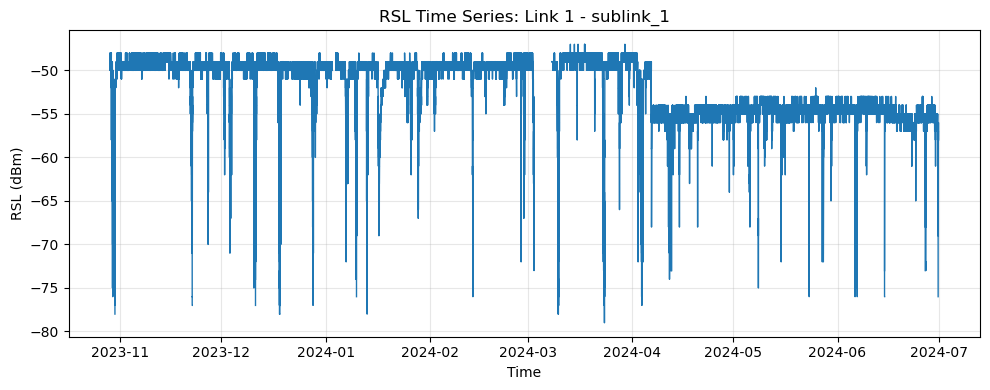

In [17]:
# Example: Choosing a specific link and extracting its RSL activations ("attenuations") for demonstration
# Let's pick the first cml_id and sublink_id as an example
chosen_cml_id = ds_links.cml_id.values[0]       # e.g., '1'
chosen_sublink_id = ds_links.sublink_id.values[0]  # e.g., 'sublink_1'

print(f"Chosen link: cml_id={chosen_cml_id}, sublink_id={chosen_sublink_id}")

# Extract RSL (Received Signal Level) time series for this link
rsl_series = ds_links['rsl'].sel(cml_id=chosen_cml_id, sublink_id=chosen_sublink_id)

# Show first few values ("activations")
print("First 10 RSL readings (dBm):")
print(rsl_series.values[:10])


plt.figure(figsize=(10,4))
plt.plot(ds_links['time'].values, rsl_series.values, lw=1)
plt.title(f"RSL Time Series: Link {chosen_cml_id} - {chosen_sublink_id}")
plt.xlabel("Time")
plt.ylabel("RSL (dBm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 4. Cleanup

In [18]:
## 4. Cleanup

# Close all datasets
close_datasets(ds_links, pws_data)

✓ Links dataset closed
✓ PWS datasets closed (37 stations)


38

## Next Steps

Now that you've successfully downloaded and explored the OpenMesh dataset, you can:

1. **Analyze link data** for rainfall estimation using signal attenuation
2. **Compare PWS and link observations** for validation
3. **Fetch additional NOAA ASOS data** using `src/fetch_data/noaa_asos/`
4. **Develop custom analysis scripts** in the `src/analysis/` directory

### Useful Resources:
- OpenSense Standard: https://github.com/OpenSenseAction/opensense-standard
- ESSD Paper: https://essd.copernicus.org/preprints/essd-2025-238/
- Repository: https://github.com/drorjac/OpenMesh